## Training the CNN on the CIFAR-10 Dataset

Preprocessed data is being uploaded into this environment for model training. For information on data preprocessing, please see documentation and the data_cleaning.ipynb notebook.

In [ ]:
# Package imports
import tensorflow as tf
from keras.models import Sequential 
from keras import layers
from keras.callbacks import EarlyStopping

2025-12-05 14:08:37.508705: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/hansen/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [33]:
# Import the data files
# Format in which the dataset will be loaded in
feature_desc = {
    "image": tf.io.FixedLenFeature([], tf.string),
    "label": tf.io.FixedLenFeature([], tf.int64),
}

# Parser to read each sample and put it into the format of the dictionary
def parse_sample(sample):
    parsed = tf.io.parse_single_example(sample, feature_desc)
    
    img = tf.io.parse_tensor(parsed["image"], out_type=tf.float32)
    img = tf.reshape(img, [32, 32, 3])
    
    label = parsed["label"]
    return img, label

# Loading in the datasets
train_ds = (
    tf.data.TFRecordDataset("train.tfrecord.gz", compression_type="GZIP")
    .map(parse_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
)
val_ds = (
    tf.data.TFRecordDataset("val.tfrecord.gz", compression_type="GZIP")
    .map(parse_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
)
test_ds = (
    tf.data.TFRecordDataset("test.tfrecord.gz", compression_type="GZIP")
    .map(parse_sample, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(64)
)

In [ ]:
# Build data augmentation processing layers
data_augmentation = Sequential([
    layers.Resizing(96, 96),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomContrast(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),])

In [ ]:
# CURRENT MODEL: 82.6% ACCURACY
model = Sequential([
    layers.Input(shape=(32, 32, 3)),
    
    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Get model summary
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,29

 Total params: 2,649,514 (10.11 MB)

 Trainable params: 2,648,618 (10.10 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Train model with early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
batch_size = 64
epochs=50
num_classes = 10

history_resized = model.fit(train_ds,batch_size=batch_size,
    epochs=epochs, verbose=1, validation_data=val_ds,
    callbacks=[early_stop]
)

loss, acc = model.evaluate(test_ds)
print(f'Test Loss: {loss}. Test Accuracy: {acc}')

Epoch 1/50
    547/Unknown 1068s 2s/step - accuracy: 0.2861 - loss: 3.3665

2025-12-05 20:54:03.408056: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/Users/hansen/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


547/547 ━━━━━━━━━━━━━━━━━━━━ 1108s 2s/step - accuracy: 0.2862 - loss: 3.3642 - val_accuracy: 0.4605 - val_loss: 1.5273
Epoch 2/50


2025-12-05 20:54:44.176857: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


547/547 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4678 - loss: 1.4714

...

2025-12-06 10:18:27.833392: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


547/547 ━━━━━━━━━━━━━━━━━━━━ 976s 2s/step - accuracy: 0.8209 - loss: 0.5140 - val_accuracy: 0.8249 - val_loss: 0.5321
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 41.


2025-12-06 10:19:06.563911: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


118/118 ━━━━━━━━━━━━━━━━━━━━ 39s 330ms/step - accuracy: 0.8165 - loss: 0.5629
Test Loss: 0.541327178478241. Test Accuracy: 0.8261333107948303


2025-12-06 10:19:45.562718: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


## Model Evaluation

As seen in the training output, the best epoch (41) yielded a validation accuracy of 83.07%. Here, I evaluate the model by visualizing training dynamics and model predictions.

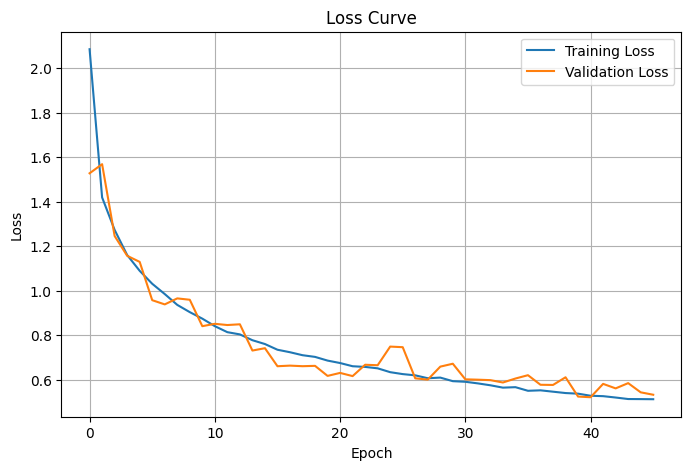

In [ ]:
# Loss curve: evolution of loss with each epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_resized.history['loss'], label='Training Loss')
plt.plot(history_resized.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

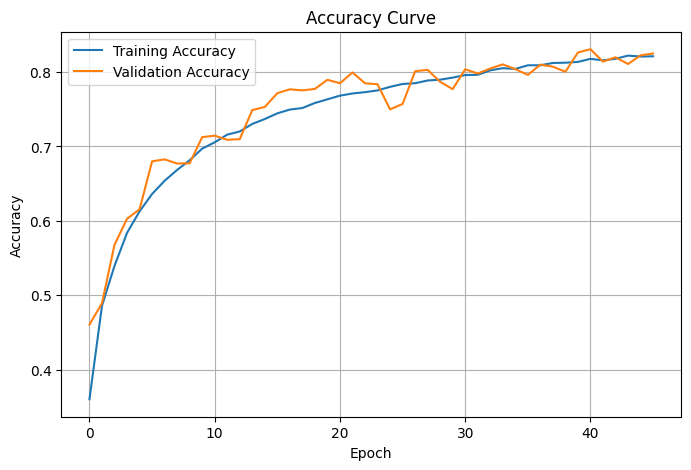

In [ ]:
# Accuracy curve: evolution of accuracy with respect to epoch
plt.figure(figsize=(8,5))
plt.plot(history_resized.history['accuracy'], label='Training Accuracy')
plt.plot(history_resized.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Confusion matrix: visualize the actual model predictions
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    # Run model prediction
    probs = model.predict(images, verbose=0)

    # Convert probability vectors → predicted class IDs
    preds = np.argmax(probs, axis=1)

    # Append to lists
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

from sklearn import metrics 
cm = metrics.confusion_matrix(y_true, y_pred)
cm

array([[643,   2,  11,   2,  19,   3,   7,  37,  11,   3],
       [  2, 693,   3,  33,   1,   3,   6,   3,   0,  12],
       [ 22,   2, 552,   0,  47,  30,   4,  45,  25,   2],
       [  1,  30,   1, 693,   0,   0,  14,   2,   2,   6],
       [ 31,   7,  26,   3, 523,  16,  11,  33,  42,  23],
       [  3,   4,  18,   5,  16, 619,   2,  25,  31,   8],
       [  1,  10,   2,   8,   3,   1, 695,   1,   0,  29],
       [ 33,   8,  19,   4,  24,  15,  11, 556,  86,  16],
       [ 14,   6,  16,   4,  16,  36,   5, 108, 588,   6],
       [  4,  21,   8,  11,  30,   8,  38,   6,   1, 634]])

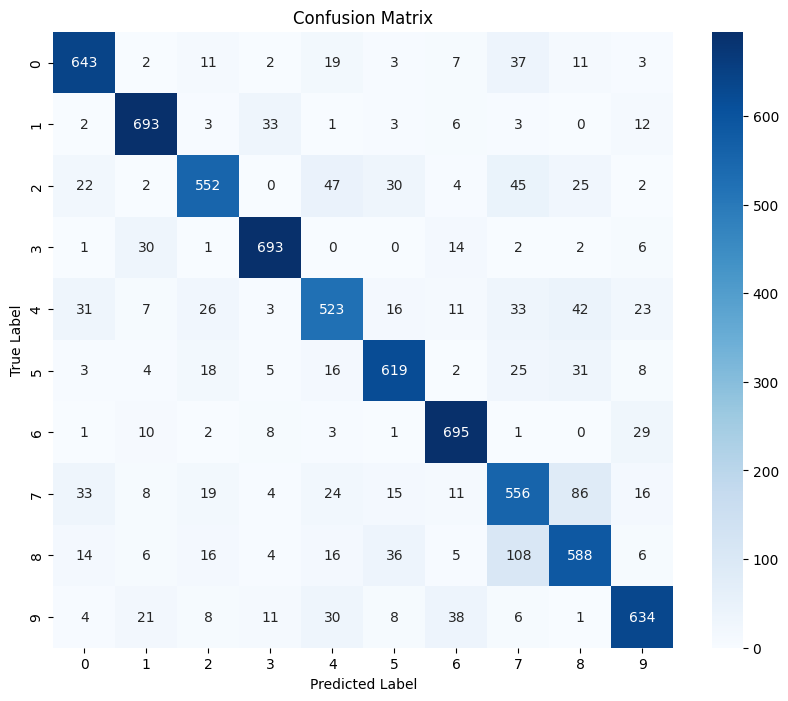

In [ ]:
# Plot the confusion matrix using a seaborn heatmap for interpretability
import matplotlib.pyplot as plt
import seaborn as sns

# Key for labels
label_map = {'frog':0, 'truck':1, 'deer':2, 'automobile':3, 'bird':4, 
             'horse':5, 'ship':6, 'cat':7, 'dog':8, 'airplane':9}

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# Save model to local storage
model.save("my_cifar10_model.keras")